In [1]:
import numpy as np
import pandas as pd
import matplotlib as plot

In [2]:
file_path = "./feature_tsv/feature_table_0.8_pruning.tsv"
df = pd.read_csv(file_path, delimiter = '\t')

#### Check correlations between ancestry and genetic variants

In [3]:
control = df['phenotype'].value_counts(normalize=True)[0]
control

0.6895306859205776

* Examine missing data below and found that 3 missing values in the radiation_status_n, 15 missig in cadd_phred 

In [4]:
df.isna().sum().sum()

0

#### Target distribution
Examine phenotype distribution


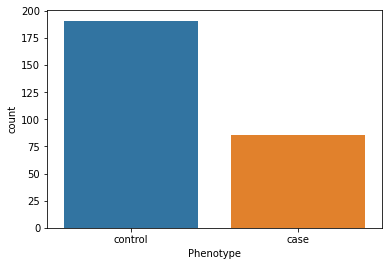

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='phenotype', data=df)
plt.xlabel('Phenotype')
xtick_labels = ['control', 'case']
plt.gca().set_xticklabels(xtick_labels)

plt.show()

#### Correlation between continous features

![corr](./plot/correlation_continous.png)

### Gradient Boosting Decision Tree

#### Hyperparameter Tuning
Grid search is employed to identify the optimal hyperparameters for the gradient boosting model, ensuring the model is well-suited for the task. To achieve this,  a cross entropy loss is then employed  as the evaluation metric and apply 5-fold cross validation for assessing the model with the large study data. 
1. Due to the unbalanced target distribution. The default scoring (mean accuracy) ill be biased towards the majority class 
2. F1 score is a harmonic mean of precision and recall, providing a balanced measure of both parameters. 
The best hyperparameters are displayed below:

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df['phenotype'], test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

clf = GradientBoostingClassifier(random_state=0)
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
}
grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


In [8]:
#export dataframe for Rstudio to make better plot
import os
plot_dir = "./plot"

if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    
grid_search.cv_results_ = pd.DataFrame(grid_search.cv_results_)
grid_search.cv_results_.to_csv(os.path.join(plot_dir, 'grid_search_result.csv'),index=False)

In [9]:
grid_search.cv_results_.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_learning_rate', 'param_max_depth', 'param_n_estimators',
       'params', 'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

![grid_search lineplot](./plot/Rplot01.png)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
{learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 100} appear to yield the best model performance per auc-roc socre. 

#### Confusion Matrix

We then use the best hyperparameters to train the model and make predictions on the investigational cohort high dose data. The confusion matrix of the predictions is shown below: 

In [10]:
%store grid_search 

Stored 'grid_search' (GridSearchCV)


In [11]:
%store -r grid_search

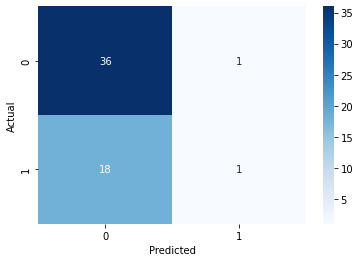

In [12]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

32 true negative, 5 false positive, 10 false negative and 9 true negative.

f1 score

In [13]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
f1

0.09523809523809525

###### Cross entropy loss
The cross entropy loss calculated on the test set is shown below:

In [14]:
import numpy as np
from sklearn.metrics import log_loss

y_pred = grid_search.best_estimator_.predict_proba(X_test)
# cross entropy loss
base_line = log_loss(y_test, y_pred)
 

In [15]:
base_line

0.6450763576755024

__Prediction Distribution__

The prediction distribution and actual distribution are shown below:

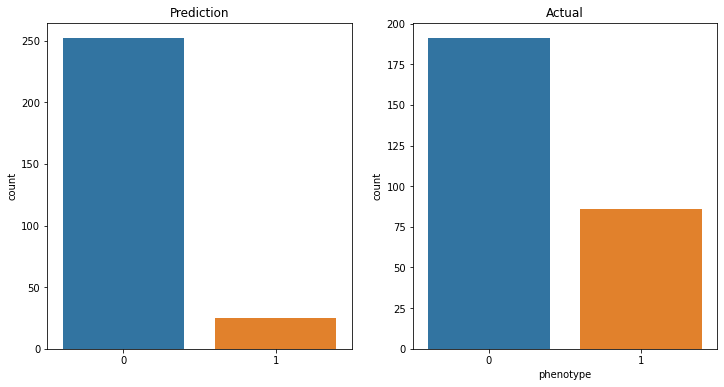

In [16]:
# prediction distribution and actual distribution
# make them subplot
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(df.drop('phenotype', axis=1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(x=y_pred, ax=ax1)
ax1.set_title('Prediction')
sns.countplot(x=df['phenotype'], ax=ax2)
ax2.set_title('Actual')
plt.show()

__Feature Importance__

The feature importance is shown below:

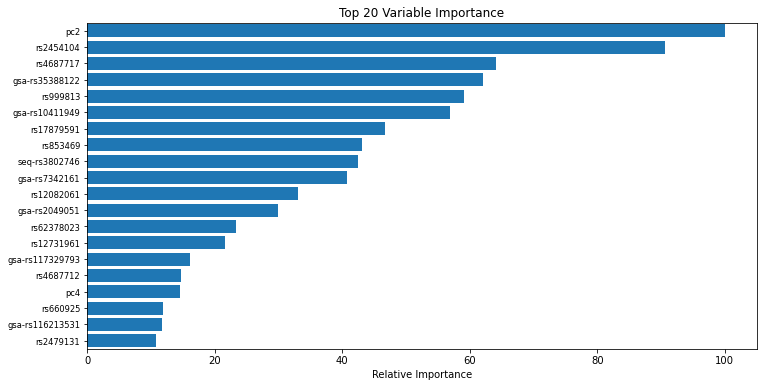

In [17]:
# feature importance
import matplotlib.pyplot as plt

feature_importance = grid_search.best_estimator_.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, df.drop('phenotype', axis=1).columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.ylim(len(feature_importance)-20, len(feature_importance))
plt.title('Top 20 Variable Importance')
plt.yticks(fontsize='small')  # Change y-ticks' font size

plt.savefig("top_20_variable_importace.pdf")

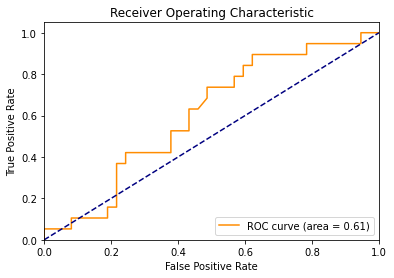

In [18]:
from sklearn.metrics import roc_curve, auc, plot_roc_curve

# Fit the classifier with the best parameters on the full training set
clf_best = GradientBoostingClassifier(**grid_search.best_params_, random_state=0)
clf_best.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf_best.predict(X_test)
y_score = clf_best.decision_function(X_test)  # get the decision scores for plotting ROC curve

# Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("ROC_full_model.pdf")


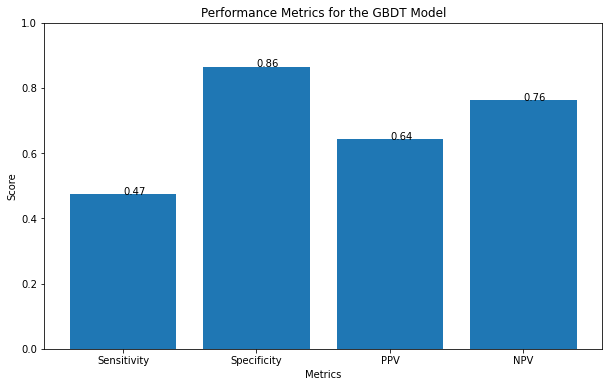

In [19]:
import matplotlib.pyplot as plt


sensitivity = 0.4738
specificity = 0.8649
ppv = 0.6429
npv = 0.7619

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.title('Performance Metrics for the GBDT Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))

plt.savefig("GBDT_performance.pdf")


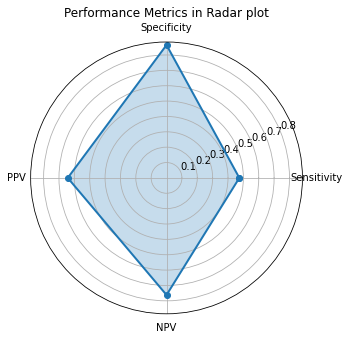

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from math import pi

# Example data
data = {'Sensitivity': sensitivity, 'Specificity': specificity, 'PPV': ppv, 'NPV': npv}
metrics = list(data.keys())
values = list(data.values())

# Bar Plot
plt.figure(figsize=(10, 5))
plt.bar(metrics, values)
plt.title('Performance Metrics')
plt.savefig("performance.pdf")

# Radar Plot
num_vars = len(metrics)

# Compute angle for each axis
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
values += values[:1]  # make the plot cyclic
angles += angles[:1]

# Initialise the radar plot
ax = plt.subplot(111, polar=True)

# Draw one axe per variable and add labels 
plt.xticks(angles[:-1], metrics)

# Draw filled area
ax.plot(angles, values, 'o-', linewidth=2)
ax.fill(angles, values, alpha=0.25)
plt.title('Performance Metrics in Radar plot')
plt.savefig("radar.pdf")



__Ablation Study__

The ablation study in machine learning is a method to evaluate the importance of individual components or features in a model by systematically removing them and measuring the impact on model performance. This helps us understand which parts of the model contribute most to its success and identify areas for potential improvement.

We then undertake an ablation study to see the effect of each feature on the model performance. The cross entropy loss is shown below:

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, log_loss, precision_score
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier

# Extract the first 14 features (i.e. excluded rsIDs)
X_train_ablation = X_train.iloc[:,0:14] # note the previous X_train has already dropped target column
X_test_ablation = X_test.iloc[:, 0:14]

# Train a new model usinng only the ablated features
ablated_model = GradientBoostingClassifier(random_state = 42)

In [22]:
# Define the hyperparameter grid for the ablated model
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
}
grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search.fit(X_train_ablation, y_train)

# Create GridSearchCV object for the ablated model
grid_search_ablated = GridSearchCV(ablated_model, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search_ablated.fit(X_train_ablation, y_train)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [100, 200, 300, 400, 500]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [23]:
%store grid_search_ablated

Stored 'grid_search_ablated' (GridSearchCV)


In [24]:
%store -r grid_search_ablated

In [25]:
print(grid_search_ablated.best_params_)
# Get the best ablated model
best_ablated_model = grid_search_ablated.best_estimator_

{'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300}


In [26]:
#Evaluate the best abalated (grid search) model on the test set

y_pred_ablated = best_ablated_model.predict(X_test_ablation)

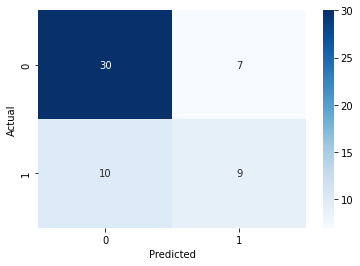

In [27]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


conf_mat = confusion_matrix(y_test, y_pred_ablated)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [28]:
#Evluate the ablated model on the test set

f1_ablated = f1_score(y_test, y_pred_ablated)
ppr_ablated = precision_score(y_test, y_pred_ablated)


Sensitivity for Best Ablated Model: 0.47368421052631576
Specificity for Best Ablated Model: 0.8108108108108109
PPV for Best Ablated Model: 0.5625
NPV for Best Ablated Model: 0.75


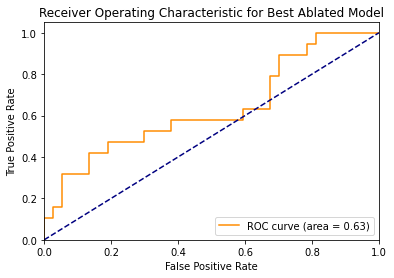

In [29]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Confusion matrix
y_pred_ablated = best_ablated_model.predict(X_test_ablation)
conf_mat_ablated = confusion_matrix(y_test, y_pred_ablated)

TN_ablated = conf_mat_ablated[0][0]
FP_ablated = conf_mat_ablated[0][1]
FN_ablated = conf_mat_ablated[1][0]
TP_ablated = conf_mat_ablated[1][1]

# Sensitivity, hit rate, recall, or true positive rate
sensitivity_ablated = TP_ablated / (TP_ablated + FN_ablated)
# Specificity or true negative rate
specificity_ablated = TN_ablated / (TN_ablated + FP_ablated) 
# Precision or positive predictive value
ppv_ablated = precision_score(y_test, y_pred_ablated)
# Negative predictive value
npv_ablated = TN_ablated / (TN_ablated + FN_ablated) 

print(f'Sensitivity for Best Ablated Model: {sensitivity_ablated}')
print(f'Specificity for Best Ablated Model: {specificity_ablated}')
print(f'PPV for Best Ablated Model: {ppv_ablated}')
print(f'NPV for Best Ablated Model: {npv_ablated}')

# ROC curve
y_pred_prob_ablated = best_ablated_model.predict_proba(X_test_ablation)[:, 1]
fpr_ablated, tpr_ablated, _ = roc_curve(y_test, y_pred_prob_ablated)
roc_auc_ablated = auc(fpr_ablated, tpr_ablated)

plt.figure()
plt.plot(fpr_ablated, tpr_ablated, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc_ablated)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Best Ablated Model')
plt.legend(loc="lower right")

plt.savefig('ROC_Ablated_Model.pdf')


In [30]:
import numpy as np
from sklearn.metrics import log_loss

y_pred_abalted = grid_search_ablated.best_estimator_.predict_proba(X_test_ablation)
# cross entropy loss
base_line = log_loss(y_test, y_pred_ablated)
 

In [31]:
base_line

10.485085640990945

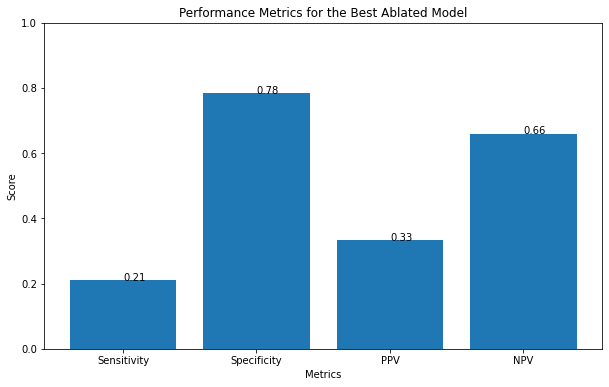

In [32]:
import matplotlib.pyplot as plt

# Your given metrics for the ablated model
sensitivity = 0.21052631578947367  # Sensitivity
specificity = 0.7837837837837838  # Specificity
ppv = 0.3333333333333333  # Positive Predictive Value
npv = 0.6590909090909091  # Negative Predictive Value

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.title('Performance Metrics for the Best Ablated Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))
plt.savefig("ablated_GBDT_performance.pdf")


## Drop PCs

In [33]:
X_train

,sex_n_male,radiation_status_n,age_mtx_initiation_year,pc1,pc2,pc3,pc4,cadd_max_agt,cadd_max_csnk1a1,cadd_max_lrp5,...,rs7936582,rs853463,rs853464,rs853469,rs874628,rs9462081,rs9658119,rs999813,seq-rs2395617,seq-rs3802746
259,1,0,16.975342,-0.009702,-0.005632,-0.008879,-0.006672,4.126,0.000,6.358,...,1,1,0,0,0,0,0,2,0,2
124,1,0,2.702186,-0.008051,-0.018583,0.006664,-0.004797,2.337,1.828,6.358,...,1,1,0,0,0,0,1,1,0,0
33,0,1,0.857534,-0.008482,-0.017604,0.008366,-0.005333,1.556,9.385,16.880,...,1,1,0,0,0,0,1,1,1,0
86,0,0,1.802740,-0.008050,-0.019170,0.007359,-0.009525,2.187,9.385,6.358,...,0,1,1,1,1,0,0,0,0,1
263,1,0,10.295890,-0.010965,0.006634,0.009796,-0.008156,2.342,7.734,6.358,...,0,1,0,0,1,0,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,0,0,4.786885,-0.008359,-0.019084,0.006978,-0.007709,2.229,9.385,6.358,...,1,1,0,0,2,0,0,0,0,1
71,0,0,4.416438,-0.007286,-0.018252,0.008285,-0.002231,2.337,1.828,6.358,...,0,1,0,0,1,0,1,1,1,1
106,0,0,14.465753,-0.007834,-0.018271,0.008108,-0.006572,1.556,1.640,6.358,...,0,2,0,0,1,0,0,1,0,0
270,0,0,4.369863,-0.008162,-0.019215,0.008460,-0.008010,2.187,4.452,3.240,...,0,1,1,1,2,0,0,0,0,0


In [34]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, f1_score, log_loss, precision_score
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier



# Extract the first 14 features (i.e. excluded rsIDs)
X_train_ablation_nopc = X_train.drop(["pc1","pc2","pc3","pc4"], axis=1)# note the previous X_train has already dropped target column
X_test_ablation_nopc = X_test.drop(["pc1","pc2","pc3","pc4"], axis=1)

# Train a new model using only the ablated features
clf = GradientBoostingClassifier(random_state = 42)

# Define the hyperparameter grid for the ablated model
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
}
grid_search_nopc = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search_nopc.fit(X_train_ablation_nopc, y_train)

# Create GridSearchCV object for the ablated model
grid_search_ablated_nopc = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")
grid_search_ablated_nopc.fit(X_train_ablation_nopc, y_train)
 

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'n_estimators': [100, 200, 300, 400, 500]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [35]:
%store grid_search_ablated_nopc

Stored 'grid_search_ablated_nopc' (GridSearchCV)


In [36]:
%store -r grid_search_ablated_nopc

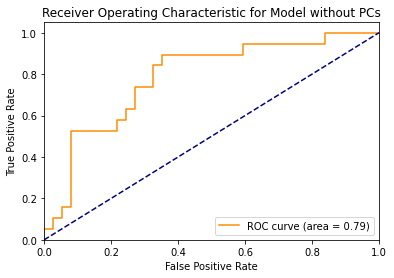

In [37]:
# ROC curve
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
y_pred_prob_ablated_nopc = grid_search_nopc.best_estimator_.predict_proba(X_test_ablation_nopc)[:, 1]
fpr_ablated_nopc, tpr_ablated_nopc, _ = roc_curve(y_test, y_pred_prob_ablated_nopc)
roc_auc_ablated_nopc = auc(fpr_ablated_nopc, tpr_ablated_nopc)

plt.figure()
plt.plot(fpr_ablated_nopc, tpr_ablated_nopc, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc_ablated_nopc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Model without PCs')
plt.legend(loc="lower right")

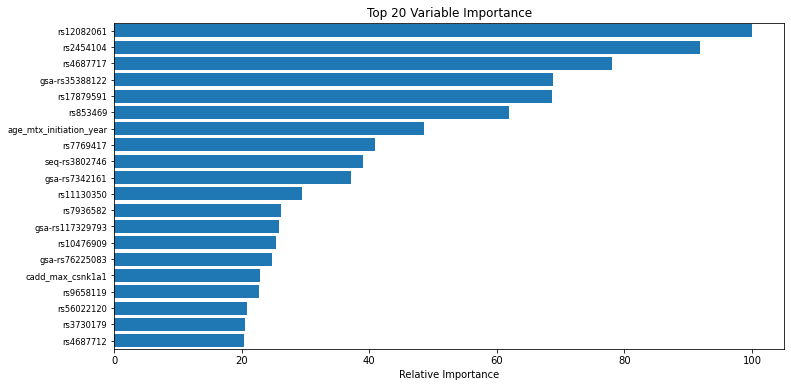

In [39]:
# feature importance
import matplotlib.pyplot as plt

feature_importance = grid_search_nopc.best_estimator_.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, df.drop(["pc1","pc2","pc3","pc4", "phenotype"], axis=1).columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.ylim(len(feature_importance)-20, len(feature_importance))
plt.title('Top 20 Variable Importance')
plt.yticks(fontsize='small')  # Change y-ticks' font size

plt.savefig("top_20_variable_importace_nopc.pdf")